In [14]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

AI Labeling

In [15]:
def get_ai_labels(model_name, file_path):
    df = pd.read_csv(file_path, index_col=False)
    df['Image'] = df['Image'].str.replace('.PNG', '', case=False)
    df['Image'] = df['Image'].str.replace('.JPG', '', case=False)
    return df

ai_dalle = get_ai_labels('dalle', "AI labeling/gender_labels_ChatGPT_individuals.csv")
ai_dalle['model'] = 'dalle'
ai_midjourney = get_ai_labels('midjourney', "AI labeling/gender_labels_Midjourney_individuals.csv")
ai_midjourney['model'] = 'midjourney'
ai_stable_diffusion = get_ai_labels('stable_diffusion', "AI labeling/gender_labels_Stable_Diffusion_individuals.csv")
ai_stable_diffusion['model'] = 'stable_diffusion'

ai_labels = pd.concat([ai_dalle, ai_midjourney, ai_stable_diffusion], axis=0)
ai_labels = ai_labels.reset_index(drop=True)
ai_labels['bank'] = ai_labels['Image'].str.replace(r'\d+$', '', regex=True)

ai_labels.rename(columns={"Gender": "ai_label"}, inplace=True)
ai_labels.rename(columns={"Confidence": "ai_confidence"}, inplace=True)

ai_labels.head()

,Image,ai_label,ai_confidence,model,bank
0,BofA01,Woman,0.993864,dalle,BofA
1,BofA02,Man,0.983340,dalle,BofA
2,BofA03,Man,0.943947,dalle,BofA
3,BofA04,Man,0.985340,dalle,BofA
4,BofA05,Man,0.906905,dalle,BofA


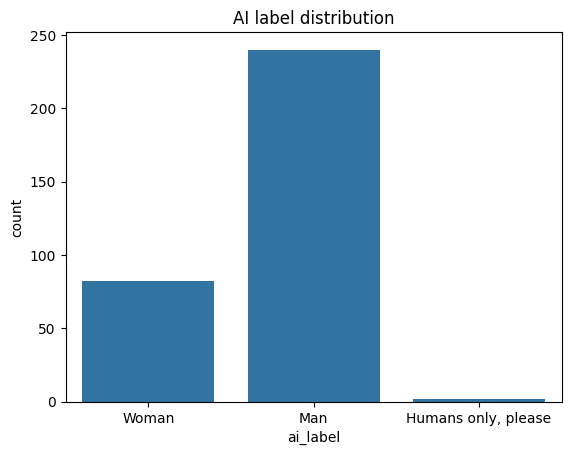

In [16]:
sns.countplot(x="ai_label", data=ai_labels)
plt.title("AI label distribution")
plt.show()

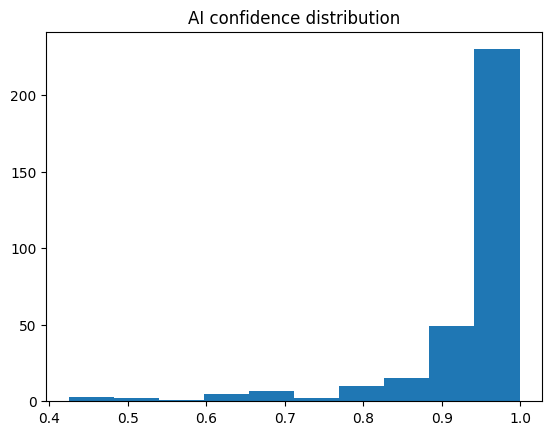

In [17]:
plt.hist(ai_labels['ai_confidence'], bins=10)
plt.title("AI confidence distribution")
plt.show()

Human Labeling

In [18]:
google_form = pd.read_csv("Human Labeling/google_form_responses.csv", index_col=False)

google_form = google_form.drop(columns=["What visual cues did you use to determine the person’s gender presentation?\n(e.g., clothing, hairstyle, body language)"])
google_form = google_form.drop(columns=["Email Address", "What gender do you identify yourself with?"])

google_form = google_form.T

google_form = google_form.reset_index(drop=True)
google_form = google_form.drop(index=0)
google_form = google_form.reset_index(drop=True)
total_response = google_form.shape[1]

google_form["human_label"] = google_form.mode(axis=1)[0]
google_form["mode_count"] = google_form.apply(lambda row: (row == row["human_label"]).sum(), axis=1) - 1
google_form["human_confidence"] = google_form["mode_count"] / total_response

human_labels = google_form[["human_label", "human_confidence"]].copy()
human_labels.head()

,human_label,human_confidence
0,Female-presenting,1.0
1,Male-presenting,1.0
2,Male-presenting,1.0
3,Male-presenting,1.0
4,Male-presenting,1.0


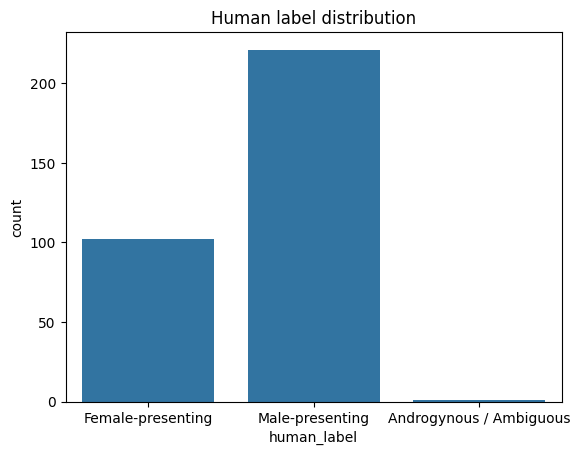

In [19]:
sns.countplot(x="human_label", data=human_labels)
plt.title("Human label distribution")
plt.show()

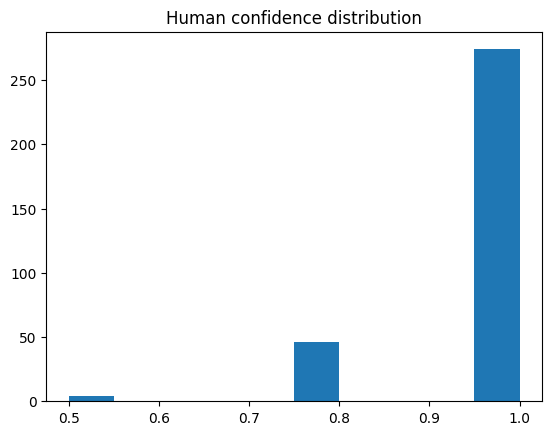

In [20]:
plt.hist(human_labels['human_confidence'], bins=10)
plt.title("Human confidence distribution")
plt.show()

Combined Labels

In [21]:
comparison_df = ai_labels.join(human_labels)

comparison_df['ai_binary'] = comparison_df['ai_label'].map({
    "Man": 0,
    "Woman": 1,
    "Humans only, please": 2
})

comparison_df['human_binary'] = comparison_df['human_label'].map({
    "Male-presenting": 0,
    "Female-presenting": 1,
    "Androgynous / Ambiguous": 2,
    "Cannot tell": 2
})

kappa_ai = cohen_kappa_score(
    comparison_df['human_binary'],
    comparison_df['ai_binary']
)

print("Cohen's Kappa (Human-AI):", kappa_ai)


Cohen's Kappa (Human-AI): 0.8364011934817535


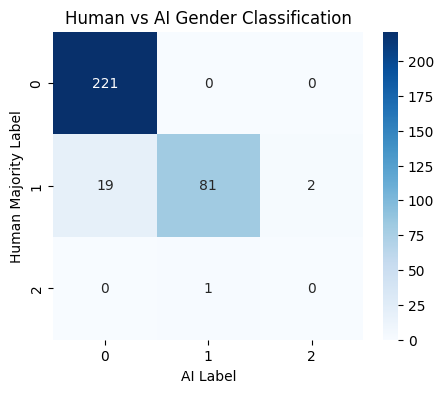

In [22]:
cm = confusion_matrix(
    comparison_df['human_binary'],
    comparison_df['ai_binary']
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("AI Label")
plt.ylabel("Human Majority Label")
plt.title("Human vs AI Gender Classification")

plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_5752\3779570335.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model_agreement = comparison_df.groupby("model").apply(


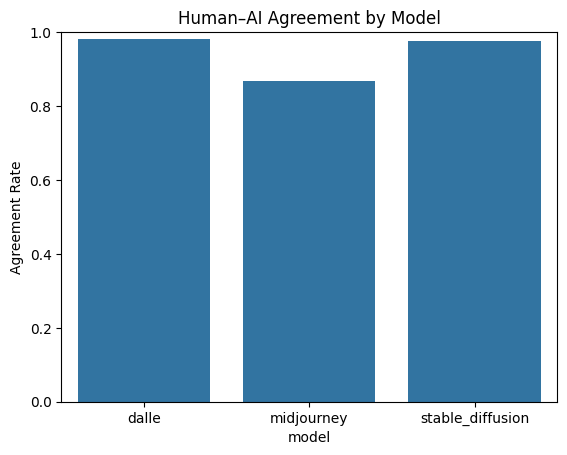

In [23]:
model_agreement = comparison_df.groupby("model").apply(
    lambda x: (x["human_binary"] == x["ai_binary"]).mean()
).reset_index(name="agreement_rate")

sns.barplot(
    data=model_agreement,
    x="model",
    y="agreement_rate"
)

plt.ylim(0,1)
plt.title("Human–AI Agreement by Model")
plt.ylabel("Agreement Rate")
plt.show()


In [24]:
final_labels = ai_labels.join(human_labels)

final_labels['label'] = None  # create empty column

final_labels.loc[(final_labels['ai_label'] == 'Man') & (final_labels['human_label'] == 'Male-presenting'), 'label'] = 0
final_labels.loc[(final_labels['ai_label'] == 'Woman') & (final_labels['human_label'] == 'Female-presenting'), 'label'] = 1

final_labels['confidence'] = (final_labels['ai_confidence']+final_labels['human_confidence'])/2
final_labels.loc[final_labels['confidence'] <= 0.85, 'label'] = None

final_labels = final_labels[final_labels['label'].notna()]

final_labels = final_labels.drop(columns=["Image", "ai_label", "ai_confidence", "human_label", "human_confidence"])

final_labels.head()

,model,bank,label,confidence
0,dalle,BofA,1,0.996932
1,dalle,BofA,0,0.991670
2,dalle,BofA,0,0.971974
3,dalle,BofA,0,0.992670
4,dalle,BofA,0,0.953453


In [25]:
final_labels.to_csv("final_labels.csv", index=True)